# XGBoost + Grey Wolf Optimizer (GWO)
Optimize XGBoost hyperparameters using Grey Wolf Optimization.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from scipy.optimize import differential_evolution

df=pd.read_csv('Metro_Interstate_Traffic_Volume.csv')

df['date_time'] = pd.to_datetime(
    df['date_time'],
    format='mixed',
    dayfirst=True
)
df['year']=df['date_time'].dt.year
df['month']=df['date_time'].dt.month
df['day']=df['date_time'].dt.day
df['hour']=df['date_time'].dt.hour
df['day_of_week']=df['date_time'].dt.dayofweek
df['is_weekend']=(df['day_of_week']>=5).astype(int)

df['lag_1']=df['traffic_volume'].shift(1)
df['lag_24']=df['traffic_volume'].shift(24)
df['rolling_mean_24']=df['traffic_volume'].shift(1).rolling(24).mean()

df=df.dropna()

df=pd.get_dummies(df,
                  columns=['holiday','weather_main','weather_description'],
                  drop_first=True)

df=df.drop(columns=['date_time'])

X=df.drop('traffic_volume',axis=1)
y=df['traffic_volume']

X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,shuffle=False)


### Grey Wolf Optimizer
The following implementation mimics the GWO optimization process for tuning XGBoost hyperparameters.

In [2]:
import numpy as np
import random

def fitness(sol):
    params={
        'n_estimators':int(sol[0]),
        'max_depth':int(sol[1]),
        'learning_rate':sol[2],
        'subsample':sol[3],
        'colsample_bytree':sol[4],
        'objective':'reg:squarederror',
        'random_state':42,
        'n_jobs':-1
    }

    model=XGBRegressor(**params)
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    rmse=np.sqrt(mean_squared_error(y_test,pred))
    return rmse

bounds=np.array([
[100,700],
[3,12],
[0.01,0.30],
[0.5,1.0],
[0.5,1.0]
])

wolves=15
iterations=20
dim=len(bounds)

positions=np.random.rand(wolves,dim)
for i in range(dim):
    positions[:,i]=bounds[i,0]+positions[:,i]*(bounds[i,1]-bounds[i,0])

alpha=beta=delta=None
alpha_score=beta_score=delta_score=1e9

history=[]

for t in range(iterations):

    for i in range(wolves):
        score=fitness(positions[i])

        if score<alpha_score:
            delta_score,beta_score,alpha_score=beta_score,alpha_score,score
            delta=beta.copy() if beta is not None else positions[i].copy()
            beta=alpha.copy() if alpha is not None else positions[i].copy()
            alpha=positions[i].copy()

        elif score<beta_score:
            delta_score=beta_score
            delta=beta.copy() if beta is not None else positions[i].copy()
            beta=positions[i].copy()

        elif score<delta_score:
            delta_score=score
            delta=positions[i].copy()

    a=2-2*(t/iterations)

    for i in range(wolves):
        for j in range(dim):
            r1,r2=random.random(),random.random()
            A1=2*a*r1-a
            C1=2*r2
            D_alpha=abs(C1*alpha[j]-positions[i,j])
            X1=alpha[j]-A1*D_alpha

            r1,r2=random.random(),random.random()
            A2=2*a*r1-a
            C2=2*r2
            D_beta=abs(C2*beta[j]-positions[i,j])
            X2=beta[j]-A2*D_beta

            r1,r2=random.random(),random.random()
            A3=2*a*r1-a
            C3=2*r2
            D_delta=abs(C3*delta[j]-positions[i,j])
            X3=delta[j]-A3*D_delta

            positions[i,j]=(X1+X2+X3)/3
            positions[i,j]=np.clip(positions[i,j],bounds[j,0],bounds[j,1])

    history.append(alpha_score)
    print(f'Iteration {t+1}: Best RMSE={alpha_score:.3f}')

print('Best Parameters:',alpha)


Iteration 1: Best RMSE=146.473
Iteration 2: Best RMSE=141.787
Iteration 3: Best RMSE=141.787
Iteration 4: Best RMSE=137.516
Iteration 5: Best RMSE=135.963
Iteration 6: Best RMSE=135.963
Iteration 7: Best RMSE=135.963
Iteration 8: Best RMSE=135.963
Iteration 9: Best RMSE=133.735
Iteration 10: Best RMSE=128.453
Iteration 11: Best RMSE=128.453
Iteration 12: Best RMSE=128.453
Iteration 13: Best RMSE=128.453
Iteration 14: Best RMSE=128.453
Iteration 15: Best RMSE=128.453
Iteration 16: Best RMSE=128.453
Iteration 17: Best RMSE=128.453
Iteration 18: Best RMSE=128.453
Iteration 19: Best RMSE=119.639
Iteration 20: Best RMSE=119.639
Best Parameters: [228.49372081   5.84480261   0.29906424   0.98655857   0.72567796]


In [6]:
best_model=XGBRegressor(
n_estimators=int(alpha[0]),
max_depth=int(alpha[1]),
learning_rate=alpha[2],
subsample=alpha[3],
colsample_bytree=alpha[4],
objective='reg:squarederror',
random_state=42)

best_model.fit(X_train,y_train)

pred=best_model.predict(X_test)

print('MAE :',mean_absolute_error(y_test,pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test,pred)))
print('R2  :',r2_score(y_test,pred))


MAE : 87.24869537353516
RMSE: 119.63884863021083
R2  : 0.8236302137374878


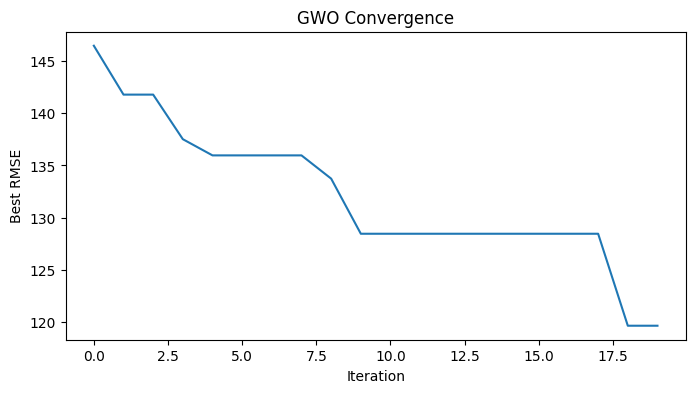

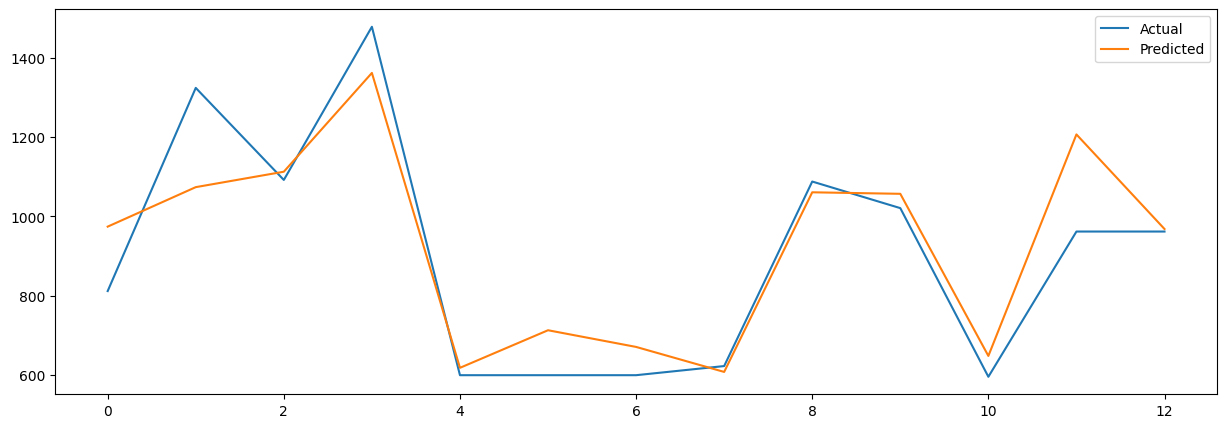

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(history)
plt.xlabel('Iteration')
plt.ylabel('Best RMSE')
plt.title('GWO Convergence')
plt.show()

plt.figure(figsize=(15,5))
plt.plot(y_test.values[:300],label='Actual')
plt.plot(pred[:300],label='Predicted')
plt.legend()
plt.show()


In [5]:
# import joblib
# joblib.dump(best_model,'xgboost_gwo_traffic_model.pkl')